<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/cnn/experiment_cnn_vs_efficientnet_cifar10_classification_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CIFAR-10 Image Classification using CNN
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------------------
# 1. Load and Preprocess Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to categorical (one-hot encoding)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# -------------------------------
# 2. Data Augmentation (Boost Accuracy)
# -------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# -------------------------------
# 3. Build CNN Model
# -------------------------------
def build_model():
    model = models.Sequential()

    # Data augmentation layer
    model.add(data_augmentation)

    # -------- Block 1 --------
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # -------- Block 2 --------
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.3))

    # -------- Block 3 --------
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.4))

    # -------- Fully Connected --------
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax'))

    return model

model = build_model()

# -------------------------------
# 4. Compile Model
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5. Callbacks (Optimization Tricks)
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-5
)

# -------------------------------
# 6. Train Model
# -------------------------------
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# -------------------------------
# 7. Evaluate Model
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\n✅ Test Accuracy: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3198 - loss: 2.0093 - val_accuracy: 0.4346 - val_loss: 1.5248 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4573 - loss: 1.5099 - val_accuracy: 0.4544 - val_loss: 1.5910 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5203 - loss: 1.3379 - val_accuracy: 0.4578 - val_loss: 1.6218 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5605 - loss: 1.2319 - val_accuracy: 0.5931 - val_loss: 1.1692 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5943 - loss: 1.1501 - val_accuracy: 0.5374 - val_loss: 1.4356 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6181 - loss: 1.0909 - val_accuracy: 0.6059 - val_loss: 1.1540 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━

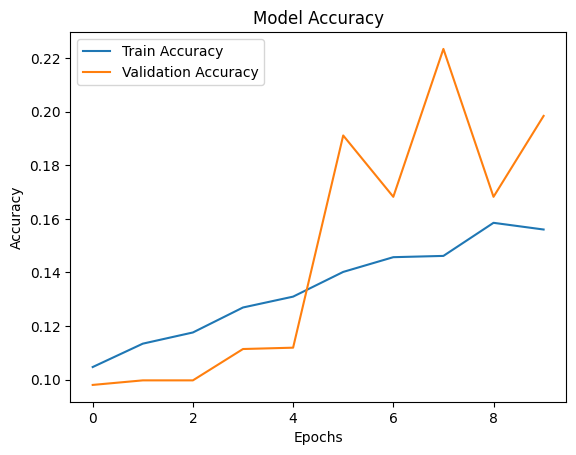

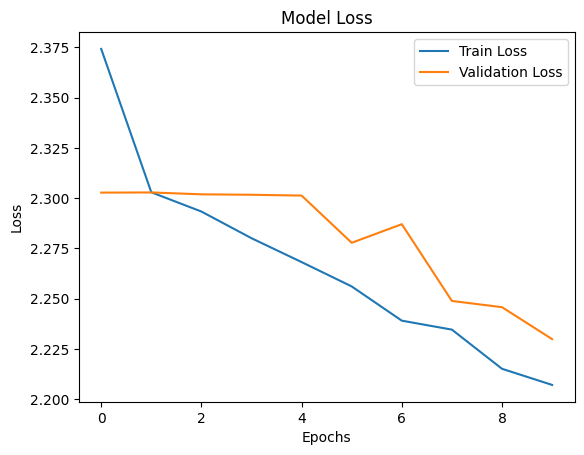

In [13]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


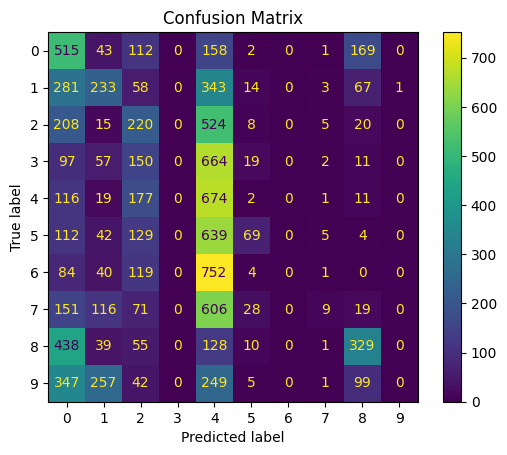

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Convert predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

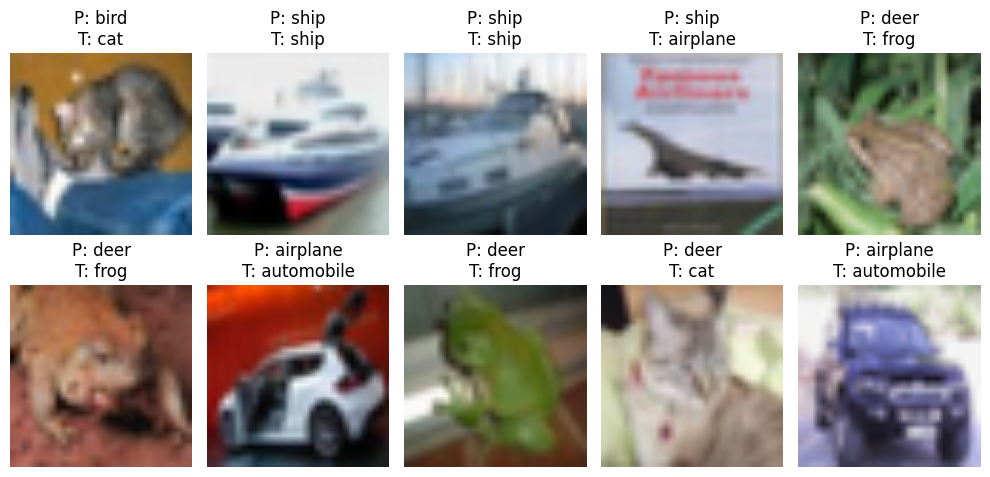

In [15]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    pred = class_names[y_pred_classes[i]]
    true = class_names[y_true[i]]

    plt.title(f"P: {pred}\nT: {true}")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


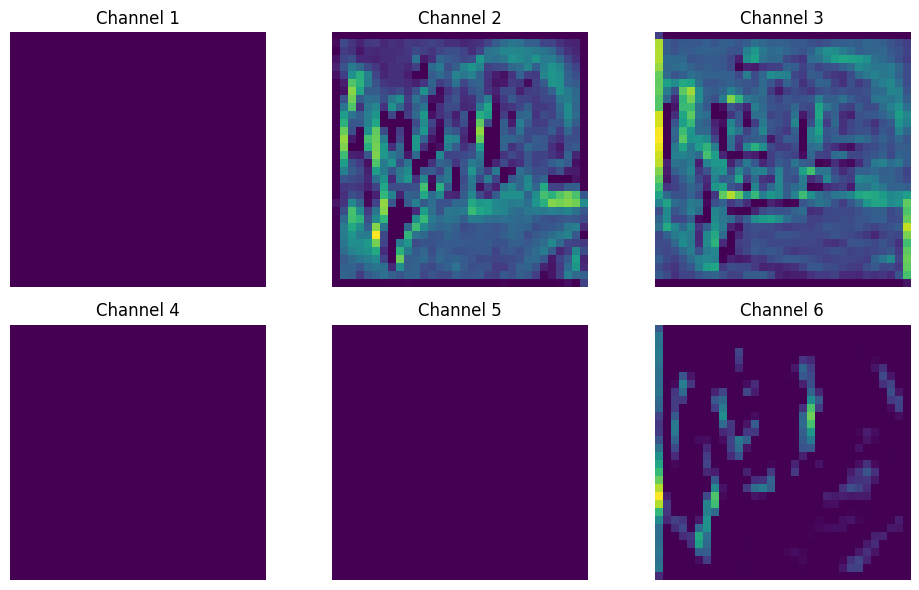

In [21]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tensorflow is imported

# Create a symbolic Input tensor for the activation model, matching the image dimensions
input_tensor_for_activation = tf.keras.Input(shape=(32, 32, 3))

# Pass the input through the data_augmentation layer (which is model.layers[0])
# This assumes model.layers[0] is indeed the data_augmentation Sequential model.
x = model.layers[0](input_tensor_for_activation)

# Find the first Conv2D layer in the original model after data_augmentation.
# This will typically be model.layers[1] in your CNN architecture.
first_conv_layer_in_model = None
for layer in model.layers[1:]: # Start from the second layer to skip data_augmentation
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer_in_model = layer
        break

if first_conv_layer_in_model is None:
    raise ValueError("No convolutional layers found in the model after data augmentation.")

# Get the output of this first Conv2D layer when fed 'x'
layer_output_to_visualize = first_conv_layer_in_model(x)

# Create the activation model using the new explicit input tensor and the obtained output
activation_model = Model(inputs=input_tensor_for_activation, outputs=layer_output_to_visualize)

# Get activations for a single test image
# Pass x_test[:1] through the activation model
activations = activation_model.predict(x_test[:1])

# Plot first layer feature maps
first_layer_activation = activations # For a single layer output, activations is directly the feature map tensor
num_channels_to_plot = min(6, first_layer_activation.shape[-1]) # Plot up to 6 channels, or fewer if fewer exist

plt.figure(figsize=(10,6))
for i in range(num_channels_to_plot):
    plt.subplot(2,3,i+1)
    # Assuming ReLU activations, values are non-negative.
    # For visualization, we can just display them directly.
    plt.imshow(first_layer_activation[0,:,:,i])
    plt.title(f'Channel {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CIFAR-10 Classification using EfficientNet
# FAST + HIGH ACCURACY (Transfer Learning)
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, models

# -------------------------------
# 1. Load Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# -------------------------------
# 2. Resize Images (IMPORTANT)
# EfficientNet expects larger input
# -------------------------------
IMG_SIZE = 96  # small but effective

x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE))

# -------------------------------
# 3. Load Pretrained Model
# -------------------------------
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model (faster training)
base_model.trainable = False

# -------------------------------
# 4. Build Final Model
# -------------------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# -------------------------------
# 5. Compile
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 6. Train (FAST)
# -------------------------------
history = model.fit(
    x_train, y_train,
    epochs=10,              # fewer epochs needed
    batch_size=128,         # faster training
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# 7. Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"\n🚀 Test Accuracy: {test_acc:.4f}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 152ms/step - accuracy: 0.1047 - loss: 2.3742 - val_accuracy: 0.0980 - val_loss: 2.3027
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.1134 - loss: 2.3029 - val_accuracy: 0.0997 - val_loss: 2.3028
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.1176 - loss: 2.2933 - val_accuracy: 0.0997 - val_loss: 2.3019
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.1269 - loss: 2.2800 - val_accuracy: 0.1114 - val_loss: 2.3017
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.1310 - loss: 2.2682 - val_accuracy: 0.1119 - val_loss: 2.3012
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.1402 - loss: 2.2561 - val_accuracy: 0.1911 - val_loss: 2.2778
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.1457 - loss: 2.2390 - val_accuracy: 0.1682 - val_loss: 2.2870
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━